# Greeks and Sensitivity Analysis

A cleaner notebook version with practical simulations, focused plots, and documented code.

## 1. Imports & Setup

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm


In [2]:
# Plots Setup

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 2. Black-Scholes class with Greeks

In [3]:
class mb_BlackScholes:
    """Black-Scholes-Merton model for European options with dividends.

    Parameters
    ----------
    S : float
        Underlying spot price.
    K : float
        Strike price.
    r : float
        Continuously compounded risk-free rate.
    T : float
        Option maturity in years.
    v : float
        Volatility as a decimal.
    q : float, default 0.0
        Continuous dividend yield.
    t : float, default 0.0
        Valuation time in years.
    """

    def __init__(self, S, K, r, T, v, q=0.0, t=0.0):
        self.S = float(S)
        self.K = float(K)
        self.r = float(r)
        self.T = float(T)
        self.v = float(v)
        self.q = float(q)
        self.t = float(t)

        if self.S <= 0:
            raise ValueError("Spot price S must be positive.")
        if self.K <= 0:
            raise ValueError("Strike K must be positive.")
        if self.v <= 0:
            raise ValueError("Volatility v must be positive.")
        if self.T <= self.t:
            raise ValueError("Maturity T must be greater than valuation time t.")

        self.tau = self.T - self.t
        self.sqrt_tau = np.sqrt(self.tau)
        self.d1 = (
            np.log(self.S / self.K)
            + (self.r - self.q + 0.5 * self.v ** 2) * self.tau
        ) / (self.v * self.sqrt_tau)
        self.d2 = self.d1 - self.v * self.sqrt_tau

    def _validate_option_type(self, option_type):
        if option_type not in {"call", "put"}:
            raise ValueError("option_type must be 'call' or 'put'.")

    def mb_price(self, option_type="call"):
        """Return the option price."""
        self._validate_option_type(option_type)
        if option_type == "call":
            return (
                self.S * np.exp(-self.q * self.tau) * norm.cdf(self.d1)
                - self.K * np.exp(-self.r * self.tau) * norm.cdf(self.d2)
            )
        return (
            self.K * np.exp(-self.r * self.tau) * norm.cdf(-self.d2)
            - self.S * np.exp(-self.q * self.tau) * norm.cdf(-self.d1)
        )

    def mb_delta(self, option_type="call"):
        """Return Delta."""
        self._validate_option_type(option_type)
        if option_type == "call":
            return np.exp(-self.q * self.tau) * norm.cdf(self.d1)
        return -np.exp(-self.q * self.tau) * norm.cdf(-self.d1)

    def mb_gamma(self):
        """Return Gamma."""
        return np.exp(-self.q * self.tau) * norm.pdf(self.d1) / (self.S * self.v * self.sqrt_tau)

    def mb_theta(self, option_type="call"):
        """Return annualized Theta."""
        self._validate_option_type(option_type)
        first_term = -(
            self.S * np.exp(-self.q * self.tau) * norm.pdf(self.d1) * self.v
        ) / (2 * self.sqrt_tau)
        if option_type == "call":
            return (
                first_term
                - self.r * self.K * np.exp(-self.r * self.tau) * norm.cdf(self.d2)
                + self.q * self.S * np.exp(-self.q * self.tau) * norm.cdf(self.d1)
            )
        return (
            first_term
            + self.r * self.K * np.exp(-self.r * self.tau) * norm.cdf(-self.d2)
            - self.q * self.S * np.exp(-self.q * self.tau) * norm.cdf(-self.d1)
        )

    def mb_vega(self):
        """Return Vega per 1.00 volatility unit."""
        return self.S * np.exp(-self.q * self.tau) * norm.pdf(self.d1) * self.sqrt_tau

    def mb_rho(self, option_type="call"):
        """Return Rho per 1.00 rate unit."""
        self._validate_option_type(option_type)
        if option_type == "call":
            return self.K * self.tau * np.exp(-self.r * self.tau) * norm.cdf(self.d2)
        return -self.K * self.tau * np.exp(-self.r * self.tau) * norm.cdf(-self.d2)

    def mb_charm(self, option_type="call"):
        """Return Charm (Delta decay)."""
        self._validate_option_type(option_type)
    
        common = -np.exp(-self.q * self.tau) * norm.pdf(self.d1) * (
            (2 * (self.r - self.q) * self.tau - self.d2 * self.v * self.sqrt_tau)
            / (2 * self.tau * self.v * self.sqrt_tau)
        )
    
        if option_type == "call":
            return common + self.q * np.exp(-self.q * self.tau) * norm.cdf(self.d1)
    
        return common - self.q * np.exp(-self.q * self.tau) * norm.cdf(-self.d1)

    def mb_volga(self):
        """Return Volga (Vomma)."""
        return self.mb_vega() * (self.d1 * self.d2 / self.v)

    def mb_vanna(self):
        """Return Vanna."""
        return -np.exp(-self.q * self.tau) * norm.pdf(self.d1) * self.d2 / self.v

    def mb_speed(self):
        """Return Speed."""
        return (
            -self.mb_gamma() / self.S
            * (self.d1 / (self.v * self.sqrt_tau) + 1)
        )

    def mb_zomma(self):
        """Return Zomma."""
        return self.mb_gamma() * ((self.d1 * self.d2 - 1) / self.v)

    def mb_color(self):
        """Return Color (Gamma decay)."""
        return (
            -np.exp(-self.q * self.tau) * norm.pdf(self.d1)
            / (2 * self.S * self.tau * self.v * self.sqrt_tau)
            * (
                2 * self.q * self.tau + 1
                + ((2 * (self.r - self.q) * self.tau - self.d2 * self.v * self.sqrt_tau)
                   / (self.v * self.sqrt_tau)) * self.d1
            )
        )


def mb_greeks_table(model):
    """Return a compact table of first- and second-order Greeks for calls and puts."""
    rows = {
        "Call Price": model.mb_price("call"),
        "Put Price": model.mb_price("put"),
        "Call Delta": model.mb_delta("call"),
        "Put Delta": model.mb_delta("put"),
        "Gamma": model.mb_gamma(),
        "Call Theta (annual)": model.mb_theta("call"),
        "Put Theta (annual)": model.mb_theta("put"),
        "Call Theta (daily)": model.mb_theta("call") / 365.0,
        "Put Theta (daily)": model.mb_theta("put") / 365.0,
        "Vega per 1.00 vol": model.mb_vega(),
        "Vega per 1 vol point": model.mb_vega() / 100.0,
        "Call Rho per 1.00 rate": model.mb_rho("call"),
        "Put Rho per 1.00 rate": model.mb_rho("put"),
        "Charm Call": model.mb_charm("call"),
        "Charm Put": model.mb_charm("put"),
        "Volga": model.mb_volga(),
        "Vanna": model.mb_vanna(),
        "Speed": model.mb_speed(),
        "Zomma": model.mb_zomma(),
        "Color": model.mb_color(),
    }
    return pd.DataFrame({"Value": rows}).round(6)

## 3. Base case example

In [4]:
# Base option parameters
S = 100.0
K = 105.0
T = 1.0
r = 0.05
q = 0.01
v = 0.20

bs = mb_BlackScholes(S=S, K=K, r=r, T=T, v=v, q=q)
base_table = mb_greeks_table(bs)
base_table

,Value
Call Price,7.491693
Put Price,8.365799
Call Delta,0.517151
Put Delta,-0.472899
Gamma,0.019718
Call Theta (annual),-5.637548
Put Theta (annual),-1.633644
Call Theta (daily),-0.015445
Put Theta (daily),-0.004476
Vega per 1.00 vol,39.435282


The table above is the base-case risk snapshot. For practical use, Delta captures directional exposure, Gamma captures convexity, Theta measures time decay, Vega measures volatility sensitivity, and Rho captures rate sensitivity.

## 4. Spot sensitivity simulation

In [5]:
spot_grid = np.linspace(70, 140, 141)

spot_df = pd.DataFrame({
    "Spot": spot_grid,
    "Call Price": [mb_BlackScholes(s, K, r, T, v, q).mb_price("call") for s in spot_grid],
    "Call Delta": [mb_BlackScholes(s, K, r, T, v, q).mb_delta("call") for s in spot_grid],
    "Gamma": [mb_BlackScholes(s, K, r, T, v, q).mb_gamma() for s in spot_grid],
})

spot_df.head()

,Spot,Call Price,Call Delta,Gamma
0,70.000000,0.220838,0.041636,0.006347
1,70.500000,0.242464,0.044897,0.006697
2,71.000000,0.265765,0.048334,0.007055
3,71.500000,0.290829,0.051953,0.007420
4,72.000000,0.317748,0.055756,0.007792


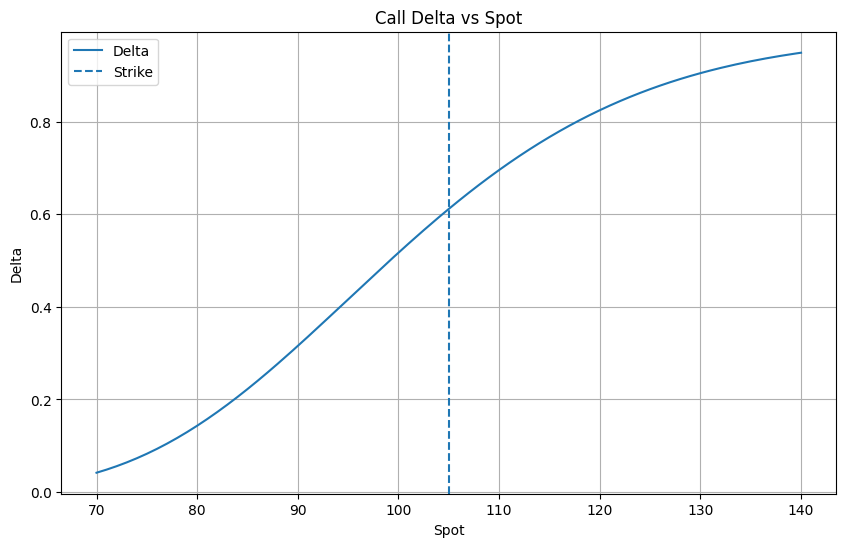

In [6]:
# Delta vs Spot
plt.figure(figsize=(10, 6))
plt.plot(spot_df["Spot"], spot_df["Call Delta"], label="Delta")
plt.axvline(K, linestyle="--", label="Strike")
plt.xlabel("Spot")
plt.ylabel("Delta")
plt.title("Call Delta vs Spot")
plt.legend()
plt.grid(True)
plt.show()


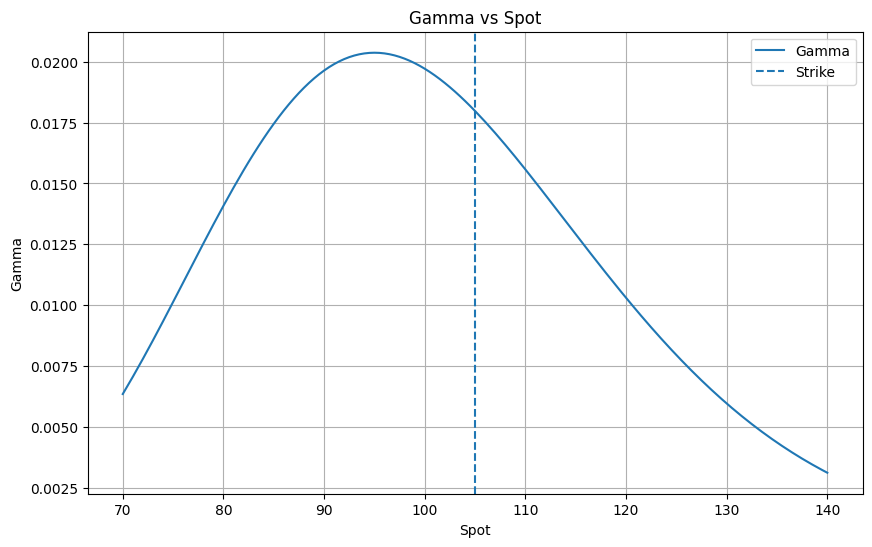

In [7]:
# Gamma vs Spot
plt.figure(figsize=(10, 6))
plt.plot(spot_df["Spot"], spot_df["Gamma"], label="Gamma")
plt.axvline(K, linestyle="--", label="Strike")
plt.xlabel("Spot")
plt.ylabel("Gamma")
plt.title("Gamma vs Spot")
plt.legend()
plt.grid(True)
plt.show()

## 5. Volatility sensitivity simulation

In [8]:
vol_grid = np.linspace(0.05, 0.60, 111)

vol_df = pd.DataFrame({
    "Volatility": vol_grid,
    "Call Price": [mb_BlackScholes(S, K, r, T, vol, q).mb_price("call") for vol in vol_grid],
    "Vega": [mb_BlackScholes(S, K, r, T, vol, q).mb_vega() for vol in vol_grid],
    "Vanna": [mb_BlackScholes(S, K, r, T, vol, q).mb_vanna() for vol in vol_grid],
})

vol_df.head()

,Volatility,Call Price,Vega,Vanna
0,0.050000,1.576887,39.050701,1.568302
1,0.055000,1.772408,39.153006,1.333489
2,0.060000,1.968375,39.230135,1.154038
3,0.065000,2.164680,39.289393,1.013868
4,0.070000,2.361247,39.335596,0.902324


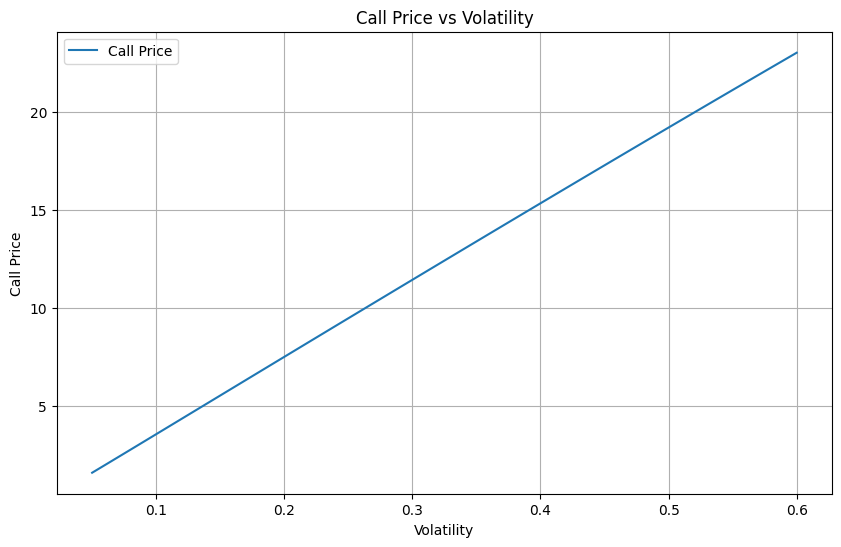

In [9]:
# Call Price vs Volatility
plt.figure(figsize=(10, 6))
plt.plot(vol_df["Volatility"], vol_df["Call Price"], label="Call Price")
plt.xlabel("Volatility")
plt.ylabel("Call Price")
plt.title("Call Price vs Volatility")
plt.legend()
plt.grid(True)
plt.show()

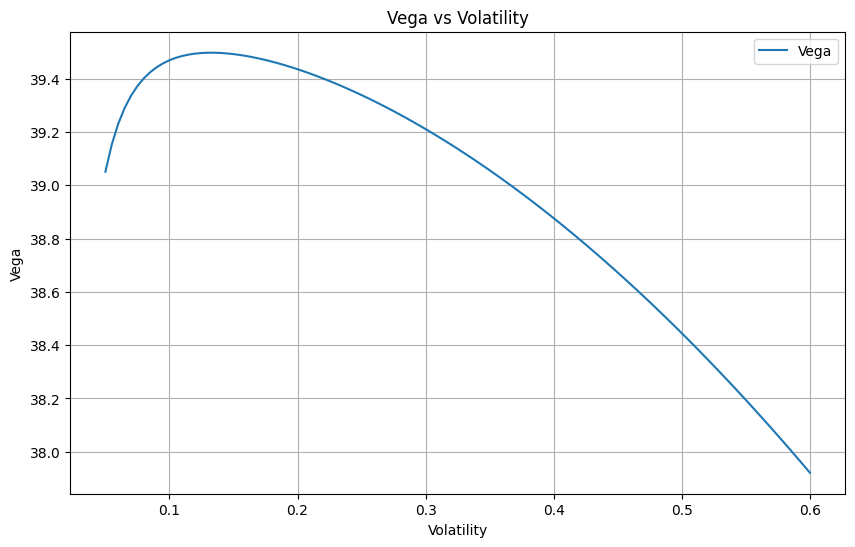

In [10]:
# Vega vs Volatility
plt.figure(figsize=(10, 6))
plt.plot(vol_df["Volatility"], vol_df["Vega"], label="Vega")
plt.xlabel("Volatility")
plt.ylabel("Vega")
plt.title("Vega vs Volatility")
plt.legend()
plt.grid(True)
plt.show()

## 6. Time-to-maturity sensitivity simulation

In [11]:
maturity_grid = np.linspace(7/365, 2.0, 120)

time_df = pd.DataFrame({
    "Maturity": maturity_grid,
    "Call Theta Daily": [mb_BlackScholes(S, K, r, tau, v, q).mb_theta("call") / 365.0 for tau in maturity_grid],
    "Call Delta": [mb_BlackScholes(S, K, r, tau, v, q).mb_delta("call") for tau in maturity_grid],
    "Gamma": [mb_BlackScholes(S, K, r, tau, v, q).mb_gamma() for tau in maturity_grid],
})

time_df.head()

,Maturity,Call Theta Daily,Call Delta,Gamma
0,0.019178,-0.018438,0.042706,0.032807
1,0.035824,-0.028189,0.108914,0.049316
2,0.052469,-0.030730,0.159473,0.052986
3,0.069115,-0.031063,0.197786,0.052875
4,0.085760,-0.030645,0.227888,0.051557


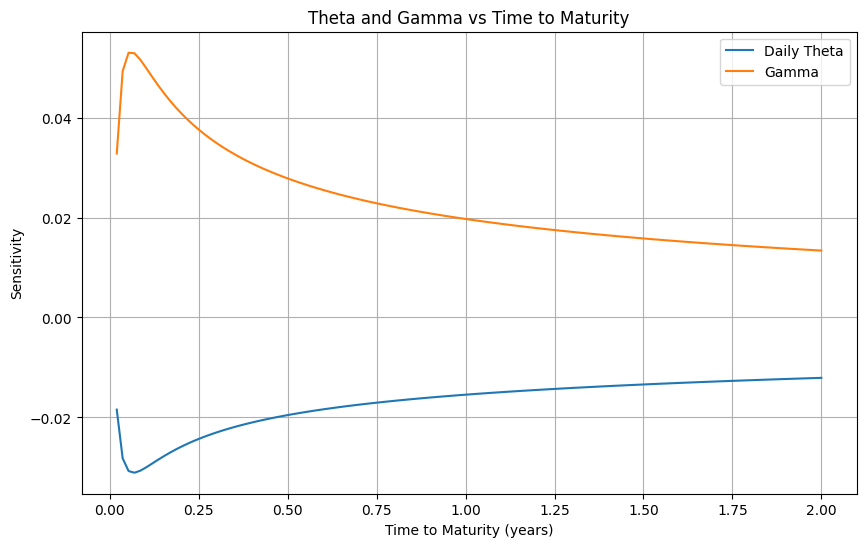

In [12]:
plt.figure()
plt.plot(time_df["Maturity"], time_df["Call Theta Daily"], label="Daily Theta")
plt.plot(time_df["Maturity"], time_df["Gamma"], label="Gamma")
plt.xlabel("Time to Maturity (years)")
plt.ylabel("Sensitivity")
plt.title("Theta and Gamma vs Time to Maturity")
plt.legend()
plt.show()

## 7. Joint spot-volatility sensitivity

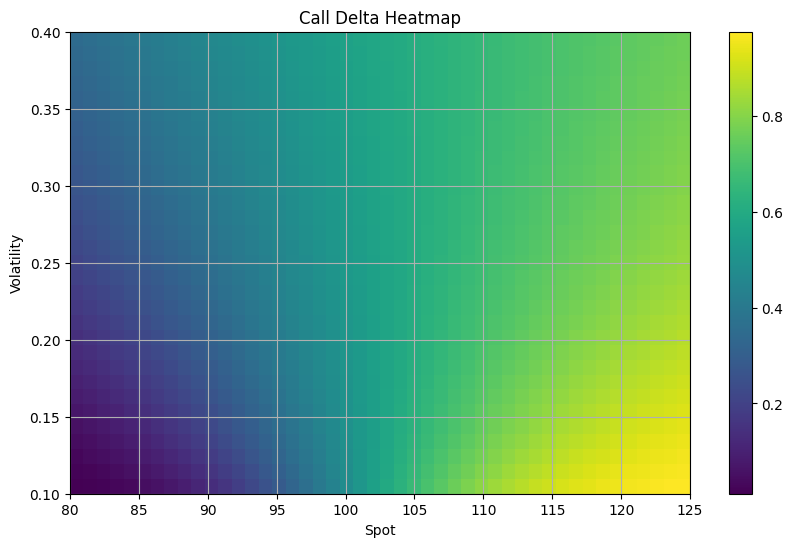

In [13]:
spot_axis = np.linspace(80, 125, 46)
vol_axis = np.linspace(0.10, 0.40, 31)

delta_surface = np.zeros((len(vol_axis), len(spot_axis)))
vega_surface = np.zeros((len(vol_axis), len(spot_axis)))

for i, vol_ in enumerate(vol_axis):
    for j, spot_ in enumerate(spot_axis):
        model = mb_BlackScholes(spot_, K, r, T, vol_, q)
        delta_surface[i, j] = model.mb_delta("call")
        vega_surface[i, j] = model.mb_vega()

fig, ax = plt.subplots()
im = ax.imshow(
    delta_surface,
    origin="lower",
    aspect="auto",
    extent=[spot_axis.min(), spot_axis.max(), vol_axis.min(), vol_axis.max()]
)
ax.set_xlabel("Spot")
ax.set_ylabel("Volatility")
ax.set_title("Call Delta Heatmap")
fig.colorbar(im, ax=ax)
plt.show()

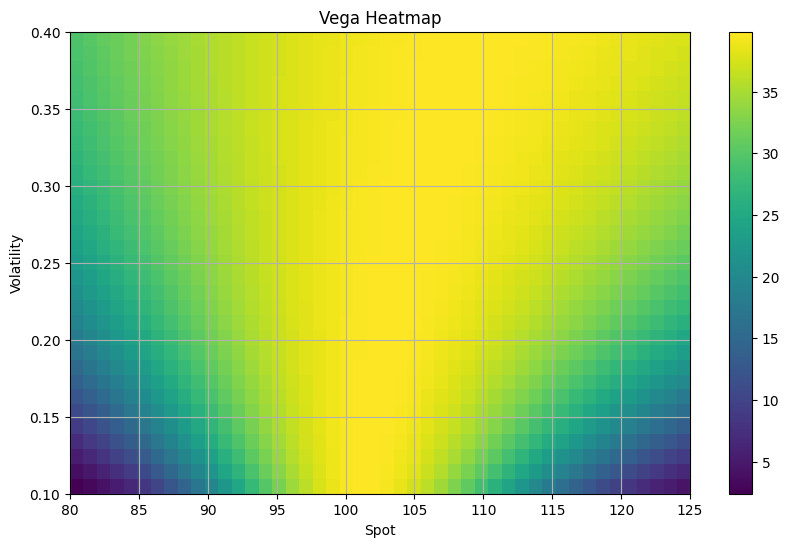

In [14]:
fig, ax = plt.subplots()
im = ax.imshow(
    vega_surface,
    origin="lower",
    aspect="auto",
    extent=[spot_axis.min(), spot_axis.max(), vol_axis.min(), vol_axis.max()]
)
ax.set_xlabel("Spot")
ax.set_ylabel("Volatility")
ax.set_title("Vega Heatmap")
fig.colorbar(im, ax=ax)
plt.show()

## 8. Compact scenario analysis

In [15]:
scenarios = [
    {"Scenario": "Base",              "S": S,        "v": v,        "T": T,          "r": r},
    {"Scenario": "Spot +5%",          "S": S * 1.05, "v": v,        "T": T,          "r": r},
    {"Scenario": "Spot -5%",          "S": S * 0.95, "v": v,        "T": T,          "r": r},
    {"Scenario": "Vol +5 pts",        "S": S,        "v": v + 0.05, "T": T,          "r": r},
    {"Scenario": "Vol -5 pts",        "S": S,        "v": v - 0.05, "T": T,          "r": r},
    {"Scenario": "30 days less time", "S": S,        "v": v,        "T": T - 30/365, "r": r},
    {"Scenario": "Rates +50 bps",     "S": S,        "v": v,        "T": T,          "r": r + 0.005},
]

scenario_rows = []

for sc in scenarios:
    model = mb_BlackScholes(sc["S"], K, sc["r"], sc["T"], sc["v"], q)

    scenario_rows.append({
        "Scenario": sc["Scenario"],
        "Call Price": model.mb_price("call"),
        "Put Price": model.mb_price("put"),
        "Call Delta": model.mb_delta("call"),
        "Put Delta": model.mb_delta("put"),
        "Gamma": model.mb_gamma(),
        "Call Theta Daily": model.mb_theta("call") / 365.0,
        "Put Theta Daily": model.mb_theta("put") / 365.0,
        "Vega / 1 vol point": model.mb_vega() / 100.0,
        "Call Rho / 1%": model.mb_rho("call") / 100.0,
        "Put Rho / 1%": model.mb_rho("put") / 100.0,
    })

scenario_df = pd.DataFrame(scenario_rows)

scenario_df = scenario_df[
    [
        "Scenario",
        "Call Price",
        "Put Price",
        "Call Delta",
        "Put Delta",
        "Gamma",
        "Call Theta Daily",
        "Put Theta Daily",
        "Vega / 1 vol point",
        "Call Rho / 1%",
        "Put Rho / 1%",
    ]
].round(6)

scenario_df

,Scenario,Call Price,Put Price,Call Delta,Put Delta,Gamma,Call Theta Daily,Put Theta Daily,Vega / 1 vol point,Call Rho / 1%,Put Rho / 1%
0,Base,7.491693,8.365799,0.517151,-0.472899,0.019718,-0.015445,-0.004476,0.394353,0.442234,-0.556557
1,Spot +5%,10.317613,6.241470,0.611763,-0.378287,0.017981,-0.016488,-0.005654,0.396473,0.539175,-0.459616
2,Spot -5%,5.156454,10.980809,0.416392,-0.573658,0.020375,-0.013704,-0.002599,0.367763,0.344008,-0.654783
3,Vol +5 pts,9.461170,10.335276,0.530461,-0.459589,0.015735,-0.017989,-0.007020,0.393382,0.435850,-0.562941
4,Vol -5 pts,5.518304,6.392410,0.501502,-0.488548,0.026328,-0.012855,-0.001885,0.394920,0.446319,-0.552472
5,30 days less time,7.021521,8.225526,0.508382,-0.482482,0.020620,-0.015908,-0.004884,0.378501,0.402153,-0.518320
6,Rates +50 bps,7.714718,8.090675,0.527002,-0.463048,0.019684,-0.016120,-0.003858,0.393678,0.449855,-0.543954
